# Gradient sanity checks and tests 
Checks:
- Gradients produced by 
    - EFGPND with stochastic trace
    - EFGPND without stochastic trace
    - Vanilla GP

- hyperparameter learning 


In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/colecitrenbaum/Documents/GPs/gp-quadrature/')
sys.path.append('/Users/colecitrenbaum/Documents/GPs/gp-quadrature/Graveyard/')
from efgpnd import efgpnd_gradient_batched
from vanilla_gp_sampling import sample_gp_fast, sample_gp_matern
import time
from utils.kernels import get_xis
from kernels.squared_exponential import SquaredExponential
from kernels.matern import Matern
import math
from utils.gradient_tests import compute_gradients_truncated, compute_gradients_vanilla
import warnings
warnings.filterwarnings("ignore", message=".*disabling cuda.*")


# Boring GP sampler

In [60]:
kernel_type = 'SquaredExponential'


# --- Parameters ---
n = 200  # Number of points
d = 1  # Dimensionality of the input space
true_length_scale =0.1
true_variance = 1
true_noise_variance = 0.2
dtype = torch.float64  # Use float64 as in the original example
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
print(f"Using device: {device}")

# --- Generate Input Points ---
# Generate random points in d-dimensional space from -1 to 1
x = torch.rand(n, d, dtype=dtype, device=device) * 2 - 1 + 100

# Generate test points (grid of points for visualization if d <= 3)
if d >= 2:
    # Create a grid of points for testing
    grid_points_per_dim = 50
    grid_points = [torch.linspace(x.min()-0.1, 0.1+x.max(), grid_points_per_dim, dtype=dtype, device=device) for _ in range(d)]
    mesh_grid = torch.meshgrid(*grid_points, indexing='ij')
    x_new = torch.stack([grid.flatten() for grid in mesh_grid], dim=1)
elif d==1:
    grid_points_per_dim = 3000
    grid_points = [torch.linspace(x.min()-0.1, 0.1+x.max(), grid_points_per_dim, dtype=dtype, device=device) for _ in range(d)]
    mesh_grid = torch.meshgrid(*grid_points, indexing='ij')
    x_new = torch.stack([grid.flatten() for grid in mesh_grid], dim=1)
else:
    # For higher dimensions, just use random test points
    x_new = torch.rand(1000, d, dtype=dtype, device=device) * 2.4 - 1.2



# --- Generate Samples ---
print(f"Generating {1} sample for n={n} points in {d} dimensions...")
start_time = time.time()

# Sample using the optimized function
if kernel_type == 'SquaredExponential':
    y = sample_gp_fast(
        x,
        length_scale=true_length_scale,
        variance=true_variance,
        noise_variance=true_noise_variance
    ).flatten().to(dtype=dtype)
else:
    y = sample_gp_matern(
        x,
        length_scale=true_length_scale,
        variance=true_variance,
        noise_variance=true_noise_variance
    ).flatten().to(dtype=dtype) 

end_time = time.time()
print(f"Generated sample of size {y.shape[0]}.")
print(f"Time taken: {end_time - start_time:.4f} seconds")


Using device: cpu
Generating 1 sample for n=200 points in 1 dimensions...
Generated sample of size 200.
Time taken: 0.0025 seconds


In [61]:
# save (x,y) to a torch file
# torch.save((x,y), f'gp_samples_{n}_{true_length_scale}_{true_variance}_{true_noise_variance}.pt')
# 

In [62]:
# load (x,y) from a torch file
# x, y = torch.load(f'gp_samples_{100_000}_{0.2}_{2}_{0.2}.pt')

In [63]:
EPSILON = 1e-4
sigmasq = torch.tensor(0.1, dtype=torch.float64)
# kernel = SquaredExponential(dimension=d, init_lengthscale=torch.tensor([0.13]), init_variance=1)

def get_init_kernel(d, init_lengthscale, init_variance,kernel_type):
    if kernel_type == 'SquaredExponential':
        return SquaredExponential(dimension=d, init_lengthscale=init_lengthscale, init_variance=init_variance)
    elif kernel_type == 'Matern':
        return Matern(dimension=d, nu=1.5, init_lengthscale=init_lengthscale, init_variance=init_variance)

init_lengthscale = 0.6
init_variance = 1
init_kernel = get_init_kernel(d, init_lengthscale, init_variance,kernel_type)
# kernel = SquaredExponential(dimension=1, lengthscale=torch.tensor([0.5*1e-2]), variance=torch.tensor(1.0))



$$(F \beta)_i  = \sum_{k=1}^M \exp(2\pi i h \langle j_k, x_ i\rangle)\beta_k$$
is a discrete fourier transform, but $\langle j_k, x_i\rangle$ are not uniformly spaced 


$$F\beta = \mathcal{F}(\beta) \in \mathbb C ^N,$$
with spacing given by 
$2\pi h (x)$

$$\frac{\partial \mathcal L}{\partial \theta} = \frac{1}{2M} \sum_{k=1}^M z_k^T((K + \sigma^2I)^{-1} \frac{\partial (K + \sigma^2 I)}{\partial \theta}) z_k - \frac{1}{2}y^T (K +\sigma^2 I)^{-1}\frac{\partial (K + \sigma^2 I)}{\partial \theta} (K+\sigma^2I)^{-1}y =I - II $$

In [64]:
x0 = x.min(dim=0).values  
x1 = x.max(dim=0).values  
# set seed
torch.manual_seed(42)
cg_tol = 1e-3
grad = efgpnd_gradient_batched(x, y, sigmasq, init_kernel, EPSILON, trace_samples=10, x0=x0, x1=x1,cg_tol = cg_tol)
print(grad)



tensor([  125.2624,   -18.5250, -3963.7186], dtype=torch.float64)


# direct inversion using the fourier approximation 
- arbitrarily close to autograd on the unapproximated log likelihood

In [65]:
# Time the gradient computation
start_time = time.time()
true_grad = compute_gradients_truncated(x, y, sigmasq, init_kernel, EPSILON)
print(true_grad)
end_time = time.time()
print(f"Time taken for gradient computation: {end_time - start_time:.2f} seconds")


tensor([  127.2267,   -20.7469, -3961.2171], dtype=torch.float64)
Time taken for gradient computation: 0.03 seconds


# auto diff, full kernel, no approximations

In [66]:

grad = compute_gradients_vanilla(x, y, sigmasq, init_kernel,kernel_type=kernel_type)
print(grad)


tensor([  126.9230,   -20.7539, -3961.0056], dtype=torch.float64)


In [67]:
from efgpnd import EFGPND
from torch.optim import Adam
max_iters = 50
J = 10

# Initialize training log
training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
}

model = EFGPND(x, y, kernel='SquaredExponential', eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.1)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J)
    optimizer.step() 

    # Record current hyperparameters in the log
    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)

    if it % 10 == 0:
        print(f"[ε={EPSILON} | J={J}] iter {it:>3}  "
              f"ℓ={lengthscale:.4g}  "
              f"σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}")

print(f'Final hyperparams: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}')


[ε=0.0001 | J=10] iter   0  ℓ=0.2644  σ_f²=1.224  σ_n²=0.2448
[ε=0.0001 | J=10] iter  10  ℓ=0.1072  σ_f²=2.789  σ_n²=0.3418
[ε=0.0001 | J=10] iter  20  ℓ=0.07691  σ_f²=2.476  σ_n²=0.1899
[ε=0.0001 | J=10] iter  30  ℓ=0.0878  σ_f²=1.25  σ_n²=0.1419
[ε=0.0001 | J=10] iter  40  ℓ=0.09222  σ_f²=0.8343  σ_n²=0.1782
Final hyperparams: ℓ=0.08308, σ_f²=0.8239, σ_n²=0.1942


In [68]:
# print(f'2d Check of gradients')
# # x2d = torch.randn(100,2).to(dtype=torch.float64)
# # y2d = torch.randn(100,).to(dtype=torch.float64)
# torch.allclose(compute_gradients_vanilla(x, y, torch.tensor(0.1, dtype=torch.float64), kernel),compute_gradients_truncated(x, y, torch.tensor(0.1, dtype=torch.float64), kernel, 1e-5))
# print(f'{d}-dimensional Check of gradients passed')

# hyper learning

In [69]:
kernel = get_init_kernel(d, init_lengthscale, init_variance,kernel_type)




In [70]:
lr = 0.001

In [71]:
# perform boring SGD using efgp1d_gradient and track hyperparameters
epsilon_values = [1e-3,1e-4]
# trace_samples_values = [1,10, 50]
# trace_samples_values  = [5,10,25]
trace_samples_values = [10]
# precomp = precompute_efgp1d_setup(x, kernel, eps=EPSILON)
min_lengthscale = 0.5*1e-2
results = []
max_iters = 50
# set seed
torch.manual_seed(42)
print(f'init_kernel: {init_kernel}')
for epsilon in epsilon_values:
    for trace_samples in trace_samples_values:
        # time the training
        start_time = time.time()
        kernel = get_init_kernel(d, init_lengthscale, init_variance,kernel_type)
        sigmasq = torch.tensor(0.1, dtype=torch.float64)  # noise variance
        log_marginals = []
        tracked_lengthscales = []
        tracked_variances = []
        tracked_noises = []

        for iter in range(max_iters):  # Perform 20 iterations of SGD
            # Track hyperparameters
            tracked_lengthscales.append(kernel.lengthscale)
            tracked_variances.append(kernel.variance)
            tracked_noises.append(sigmasq)
            # grad = efgp1d_gradient(x, y, sigmasq, kernel, epsilon, trace_samples=trace_samples)
            if iter<40:
                grad = efgpnd_gradient_batched(x, y, sigmasq, kernel, epsilon, trace_samples=5, x0=x0, x1=x1)
            else:
                grad = efgpnd_gradient_batched(x, y, sigmasq, kernel, epsilon, trace_samples=trace_samples, x0=x0, x1=x1)

            # grad = efgp1d_gradient_batched(x, y, sigmasq, kernel, EPSILON, trace_samples, precomp)
            # just clamping this for now
            kernel.lengthscale = max((torch.exp(np.log(kernel.lengthscale) - lr *kernel.lengthscale* grad[0])).item(),min_lengthscale)
            if iter < 3 and kernel.lengthscale < 0.05:
                lr = lr * 0.5  # Reduce learning rate by factor of 10
                print(f"Reduced learning rate to {lr} at iteration {iter} due to small lengthscale")
                kernel = get_init_kernel(d, init_lengthscale, init_variance,kernel_type)
            else:
                test_variance = max((torch.exp(np.log(kernel.variance) - lr *kernel.variance* grad[1])).item(),torch.tensor(1e-5))
                kernel.variance = max((torch.exp(np.log(kernel.variance) - lr *kernel.variance* grad[1])).item(),torch.tensor(1e-5))
                lognoise = torch.log(sigmasq) - lr * sigmasq * grad[-1]
                sigmasq = max((torch.exp(lognoise)), torch.tensor(1e-5))
            # print(f"Iteration {iter}: lengthscale = {kernel.lengthscale}, variance = {kernel.variance}, noise = {sigmasq}")
            if iter % 10 == 0:
                print(f'iter: {iter}')
                print(f'grad: ', grad)
                print(f'lengthscale: {kernel.lengthscale}')
                print(f'variance: {kernel.variance}')
                print(f'noise: {sigmasq}')
            # sigmasq = sigmasq - 0.0001 * grad[2]



            # beta, xis, ytrg = efgp1d(x_input, y_input, sigmasq=sigmasq, kernel=kernel, eps=epsilon, x_new=x, opts={'get_var': True, 'method': 'cholesky', 'get_log_marginal_likelihood': True})
            # log_marginals.append(kernel.log_marginal(x, y, sigmasq))
            # if iter % 10 == 0:
            #     print(f"Epsilon {epsilon}, Trace samples {trace_samples}, Iteration {iter}: log marginal = {log_marginals[-1]}, grad = {grad}, lengthscale = {kernel.lengthscale}, variance = {kernel.variance}, noise = {sigmasq.item()}")

            # if torch.norm(grad) < 1e-5:
            #     print(f"Gradient is small at iteration {iter}. Stopping early.")
            #     break
        # Store results for this epsilon and trace_samples value
        results.append({
            'epsilon': epsilon,
            'trace_samples': trace_samples,
            'log_marginals': log_marginals,
            'tracked_lengthscales': tracked_lengthscales,
            'tracked_variances': tracked_variances,
            'tracked_noises': tracked_noises,
            'iters': iter
        })
        end_time = time.time()
        print(f"Training time for epsilon {epsilon}, trace_samples {trace_samples}: {end_time - start_time:.2f} seconds")


init_kernel: dimension=1 hypers=['lengthscale', 'variance'] num_hypers=3 init_lengthscale=0.6 init_variance=1.0
iter: 0
grad:  tensor([  119.2633,   -17.1810, -3967.2753], dtype=torch.float64)
lengthscale: 0.5585653781890869
variance: 1.017329454421997
noise: 0.1486950731810947
iter: 10
grad:  tensor([ 15.2596,  -4.0638, -95.2882], dtype=torch.float64)
lengthscale: 0.4466620683670044
variance: 1.0902435779571533
noise: 0.3889840721509267
iter: 20
grad:  tensor([  9.4844,  -1.0688, -24.8598], dtype=torch.float64)
lengthscale: 0.41048479080200195
variance: 1.1247456073760986
noise: 0.47018934780554045
iter: 30
grad:  tensor([18.1881, -1.1760, -7.6291], dtype=torch.float64)
lengthscale: 0.3838846981525421
variance: 1.1538838148117065
noise: 0.49675400446641743
iter: 40
grad:  tensor([23.8403, -1.2219, -1.6217], dtype=torch.float64)
lengthscale: 0.3485203981399536
variance: 1.1799885034561157
noise: 0.5028525459487022
Training time for epsilon 0.001, trace_samples 10: 1.17 seconds
iter: 0


In [72]:
# perform sgd on the vanilla kernel 
# time it 
start = time.time()
kernel = get_init_kernel(d, init_lengthscale, init_variance,kernel_type)
sigmasq = torch.tensor(0.1, dtype=torch.float64)  # noise variance
log_marginals = []
tracked_lengthscales_vanilla = []
tracked_variances_vanilla = []
tracked_noises_vanilla = []
for iter in range(max_iters):  # Perform 20 iterations of SGD
        # Track hyperparameters
    tracked_lengthscales_vanilla.append(kernel.lengthscale)
    tracked_variances_vanilla.append(kernel.variance)
    tracked_noises_vanilla.append(sigmasq.item())
    grad = compute_gradients_vanilla(x, y, sigmasq, kernel,kernel_type=kernel_type)
    # kernel.lengthscale = kernel.lengthscale - lr * grad[0]
    kernel.lengthscale = (torch.exp(np.log(kernel.lengthscale) - lr *kernel.lengthscale* grad[0])).item()
    kernel.variance = (torch.exp(np.log(kernel.variance) - lr *kernel.variance* grad[1])).item()
    lognoise = torch.log(sigmasq) - lr * sigmasq * grad[-1]
    sigmasq = (torch.exp(lognoise))
end = time.time()
print("Time taken for vanilla SGD: ", end-start)

Time taken for vanilla SGD:  0.08292913436889648


In [73]:



results_exacttrace = []  # Will store the results for each epsilon value.
max_iters = 50
# Loop over each epsilon value
for epsilon in epsilon_values:
    # Re-initialize kernel, learning rate, and other parameters for each run.
    kernel = get_init_kernel(d, init_lengthscale, init_variance,kernel_type)
    sigmasq = torch.tensor(0.1, dtype=torch.float64)  # noise variance

    # Ensure 'sigmasq' is defined. If not, set it to an initial value, e.g.:

    # Reset tracking lists for each epsilon run.
    log_marginals = []
    tracked_lengthscales = []
    tracked_variances = []
    tracked_noises = []
    
    # Run SGD for a fixed number of iterations (here 20 iterations)
    for iter in range(max_iters):
        # Compute gradients using the current epsilon value.
        # Track the updated hyperparameters.
        tracked_lengthscales.append(kernel.lengthscale)
        tracked_variances.append(kernel.variance)
        tracked_noises.append(sigmasq.item())
        grad = compute_gradients_truncated(x, y, sigmasq, kernel, EPSILON=epsilon)
        
        # Update kernel hyperparameters according to the gradients.
        # kernel.lengthscale = kernel.lengthscale - lr * grad[0]
        kernel.lengthscale = (torch.exp(np.log(kernel.lengthscale) - lr *kernel.lengthscale* grad[0])).item()
        kernel.variance = (torch.exp(np.log(kernel.variance) - lr *kernel.variance* grad[1])).item()
        lognoise = torch.log(sigmasq) - lr * sigmasq * grad[-1]
        sigmasq = (torch.exp(lognoise))
        # Optionally update noise if needed:
        # sigmasq = sigmasq - 0.0001 * grad[2]
        

        
        # Run the model prediction or log marginal likelihood evaluation.
        # beta, xis, ytrg = efgp1d(
        #     x_input, y_input,
        #     sigmasq=sigmasq,
        #     kernel=kernel,
        #     eps=epsilon,
        #     x_new=x,
        #     opts={'get_var': True, 'method': 'cholesky', 'get_log_marginal_likelihood': True}
        # )
        
        # # Compute and store the log marginal likelihood.
        # log_marginals.append(kernel.log_marginal(x, y, sigmasq))
        
        # Optionally, print intermediate diagnostics every 10 iterations.
        if iter % 10 == 0:
            print(f"Epsilon {epsilon}, Iteration {iter}:  "
                  f"grad = {grad}, lengthscale = {kernel.lengthscale}, "
                  f"variance = {kernel.variance}, noise = {sigmasq.item()}")
        # break if grad is small
        if torch.norm(grad) < 1e-5:
            print(f"Gradient is small at iteration {iter}. Stopping early.")
            break
    
    # Save the results for this epsilon value into the results list.
    results_exacttrace.append({
        'epsilon': epsilon,
        'log_marginals': log_marginals,
        'tracked_lengthscales': tracked_lengthscales,
        'tracked_variances': tracked_variances,
        'tracked_noises': tracked_noises,
        'iters': iter
    })

# After looping over all epsilon values, 'results_exacttrace' contains the detailed trace for each run.


Epsilon 0.001, Iteration 0:  grad = tensor([  128.3790,   -20.7063, -3962.5730], dtype=torch.float64), lengthscale = 0.5555186867713928, variance = 1.0209221839904785, noise = 0.14862516742665435
Epsilon 0.001, Iteration 10:  grad = tensor([ 26.1634,  -4.1935, -95.8960], dtype=torch.float64), lengthscale = 0.44772928953170776, variance = 1.0990910530090332, noise = 0.3889667223150462
Epsilon 0.001, Iteration 20:  grad = tensor([ 20.3329,  -2.7953, -21.6445], dtype=torch.float64), lengthscale = 0.40796419978141785, variance = 1.1400569677352905, noise = 0.4690638107082084
Epsilon 0.001, Iteration 30:  grad = tensor([22.0510, -2.3618, -5.5523], dtype=torch.float64), lengthscale = 0.3759254813194275, variance = 1.173645257949829, noise = 0.49507817103515733
Epsilon 0.001, Iteration 40:  grad = tensor([29.7684, -2.3271,  0.3606], dtype=torch.float64), lengthscale = 0.3426569104194641, variance = 1.2063888311386108, noise = 0.4998940490060781
Epsilon 0.0001, Iteration 0:  grad = tensor([  1

# making a loss landscape

In [74]:
# calculate log marginal over a grid of lengthscales and variances
# Create grid centered around true values, ensuring init values are included
lengthscale_min = max(0.00001, min(init_kernel.lengthscale+0.01, true_length_scale - 0.1))
lengthscale_max = max(init_kernel.lengthscale+0.01, true_length_scale + 0.1)

variance_min = max(0.001, min(init_kernel.variance, true_variance - 2))
variance_max = max(init_kernel.variance, true_variance + 2)

lengthscales = torch.linspace(lengthscale_min, lengthscale_max, 50)
variances = torch.linspace(variance_min, variance_max, 50)
log_marginals_grid = torch.zeros((len(lengthscales), len(variances)))

# Calculate log marginal likelihood for each grid point
for i, lengthscale in enumerate(lengthscales):
    for j, variance in enumerate(variances):
        if kernel_type == 'SquaredExponential':
            kernel = SquaredExponential(dimension=d, init_lengthscale=lengthscale.item(), init_variance=variance.item())
        elif kernel_type == 'Matern':
            kernel = Matern(dimension=d, nu=1.5, init_lengthscale=lengthscale.item(), init_variance=variance.item())

        log_marginals_grid[i, j] = kernel.log_marginal(x, y, sigmasq)



/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_13388/2016973872.py:53: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(true_length_scale, true_variance, color='black', edgecolors='w', s=50, marker='x', label='True', zorder=12)
/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_13388/2016973872.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[.01, 0, 0.75, 1])


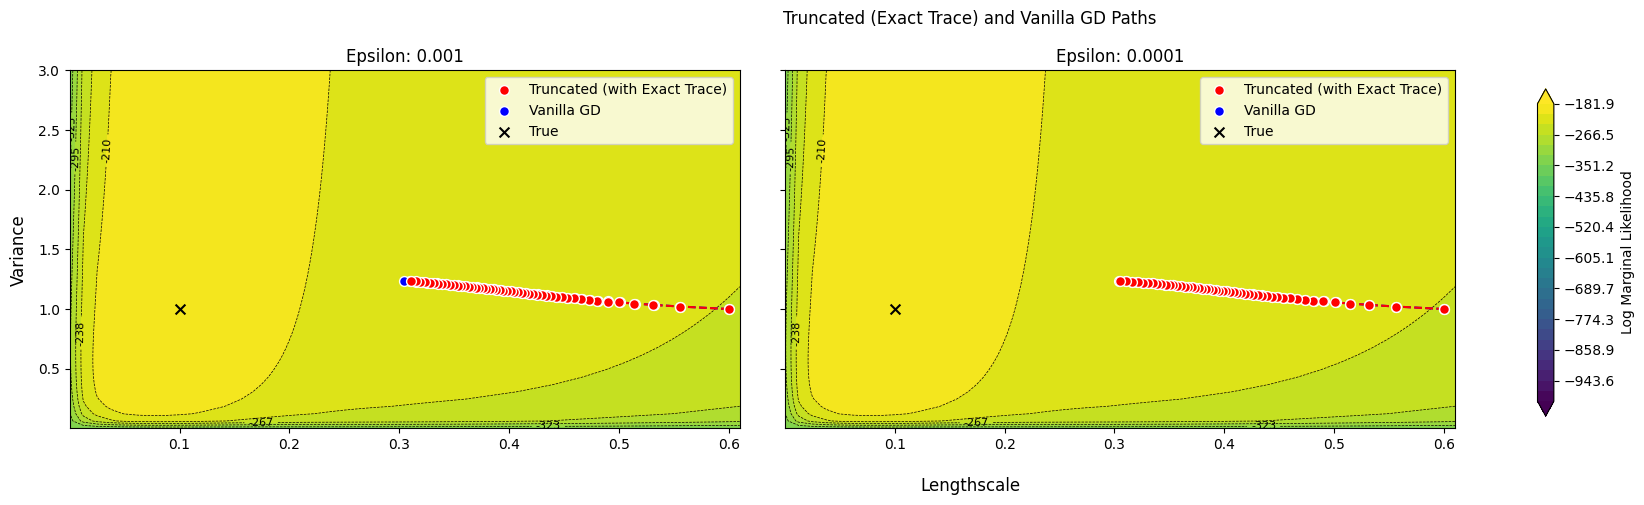

In [75]:

# For numerical stability, clip extremely low log marginal values.
log_marginal_clipped = np.clip(log_marginals_grid, -100, log_marginals_grid.max())
log_marginal_clipped = log_marginals_grid

# Set up detailed filled contour levels and slightly fewer levels for the line overlay.
fill_levels = np.linspace(-1000, log_marginals_grid.max(), 30)
line_levels = np.linspace(-1000, log_marginals_grid.max(), 30)

# Number of epsilon runs you have in results_exacttrace.
n_plots = len(results_exacttrace)

# Choose a layout: here we use 2 rows and as many columns as needed.
n_rows = 1
n_cols = int(np.ceil(n_plots / n_rows))

# Convert vanilla SGD tracking lists to arrays.
tracked_lengthscales_vanilla_arr = np.array(tracked_lengthscales_vanilla)
tracked_variances_vanilla_arr  = np.array(tracked_variances_vanilla)

# Create a grid of subplots for visualization.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to a 1D list for easy iteration

# Iterate over each subplot (each corresponding to a different epsilon value)
for i, ax in enumerate(axes):
    if i < n_plots:
        # Retrieve the current epsilon run's results.
        res = results_exacttrace[i]
        tracked_lengthscales_path = np.array(res.get('tracked_lengthscales', []))
        tracked_variances_path   = np.array(res.get('tracked_variances', []))
        
        # Plot the filled contours of log marginal likelihood.
        cf = ax.contourf(lengthscales, variances, log_marginal_clipped.T,
                         levels=fill_levels, cmap='viridis', extend='both')
        # Overlay contour lines.
        cs = ax.contour(lengthscales, variances, log_marginal_clipped.T,
                        levels=line_levels, colors='k', linewidths=0.5)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%1.0f')
        

        
        # Plot the results_exacttrace SGD path for the current epsilon:
        ax.scatter(tracked_lengthscales_path, tracked_variances_path,
                   color='red', edgecolors='w', s=50, label='Truncated (with Exact Trace)', zorder=11)
        ax.plot(tracked_lengthscales_path, tracked_variances_path,
                color='red', linestyle='--', zorder=10)
        # Plot the vanilla SGD path:
        ax.scatter(tracked_lengthscales_vanilla_arr, tracked_variances_vanilla_arr,
                   color='blue', edgecolors='w', s=50, label='Vanilla GD', zorder=10)
        ax.plot(tracked_lengthscales_vanilla_arr, tracked_variances_vanilla_arr,
                color='blue', linestyle='--', zorder=9)
        # plot an x at the true lengthscale and variance
        ax.scatter(true_length_scale, true_variance, color='black', edgecolors='w', s=50, marker='x', label='True', zorder=12)
        
        # Set a title that indicates the epsilon and trace_samples for this run.
        ax.set_title(f"Epsilon: {res['epsilon']}", fontsize=12)
        ax.legend(fontsize=10)
    else:
        # If there is no data to plot in this subplot, hide the axis.
        ax.axis('off')

# Add a colorbar to the entire figure using the last filled contour plot reference (cf).
cbar = fig.colorbar(cf, ax=axes.tolist(), label='Log Marginal Likelihood',
                    shrink=0.85, orientation='vertical', pad=0.02)
cbar.ax.tick_params(labelsize=10)

# Label the common x and y axes.
fig.supxlabel('Lengthscale', fontsize=12)
fig.supylabel('Variance', fontsize=12)

# Adjust layout to fit all subplots and the colorbar nicely.
plt.suptitle('Truncated (Exact Trace) and Vanilla GD Paths')

plt.tight_layout(rect=[.01, 0, 0.75, 1])
# plt.savefig('/Users/colecitrenbaum/Documents/GPs/Figures/vanilla_vs_truncated.png', dpi=300)
plt.show()


# next a figure that compares stoch trace estimate w vanilla SGD

In [76]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel,RBF

# Assume x, y are already defined as numpy arrays of shape (n_samples, n_features) and (n_samples,)
# Use Matern 3/2 kernel with automatic hyperparameter optimization, including noise variance
if kernel_type == 'SquaredExponential':
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level_bounds=(1e-5, 1e1))
elif kernel_type == 'Matern':
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level_bounds=(1e-5, 1e1))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=False)
gp.fit(x, y)

print("Learned kernel:", gp.kernel_)
print("Kernel hyperparameters:", gp.kernel_.get_params())
# Extract the learned variance (signal variance), length scale, and noise variance from the fitted kernel
# For the kernel: ConstantKernel * Matern + WhiteKernel
# The signal variance is the value of the ConstantKernel, the length scale is from the Matern kernel,
# and the noise variance is from the WhiteKernel

learned_kernel = gp.kernel_

# Extract variance (ConstantKernel's constant_value), length scale, and noise variance
if hasattr(learned_kernel, 'k1') and hasattr(learned_kernel.k1, 'k1'):
    scikit_variance = learned_kernel.k1.k1.constant_value
    scikit_length_scale = learned_kernel.k1.k2.length_scale
    scikit_noise_variance = learned_kernel.k2.noise_level
else:
    # fallback for other kernel structures
    scikit_variance = learned_kernel.k1.constant_value
    scikit_length_scale = learned_kernel.k2.length_scale
    scikit_noise_variance = learned_kernel.k2.noise_level

print("Learned variance (signal variance):", float(scikit_variance))
print("Learned length scale:", float(scikit_length_scale))
print("Learned noise variance:", float(scikit_noise_variance))


Learned kernel: 0.962**2 * RBF(length_scale=0.0853) + WhiteKernel(noise_level=0.175)
Kernel hyperparameters: {'k1': 0.962**2 * RBF(length_scale=0.0853), 'k2': WhiteKernel(noise_level=0.175), 'k1__k1': 0.962**2, 'k1__k2': RBF(length_scale=0.0853), 'k1__k1__constant_value': np.float64(0.9251334390549953), 'k1__k1__constant_value_bounds': (0.001, 1000.0), 'k1__k2__length_scale': np.float64(0.08531761159410013), 'k1__k2__length_scale_bounds': (0.01, 100.0), 'k2__noise_level': np.float64(0.17488675695348632), 'k2__noise_level_bounds': (1e-05, 10.0)}
Learned variance (signal variance): 0.9251334390549953
Learned length scale: 0.08531761159410013
Learned noise variance: 0.17488675695348632


/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_13388/2070253180.py:76: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(true_length_scale, true_variance, color='black', edgecolors='w', s=50, marker='x', label='True', zorder=12)
/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_13388/2070253180.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[.01, 0, 0.75, 1])


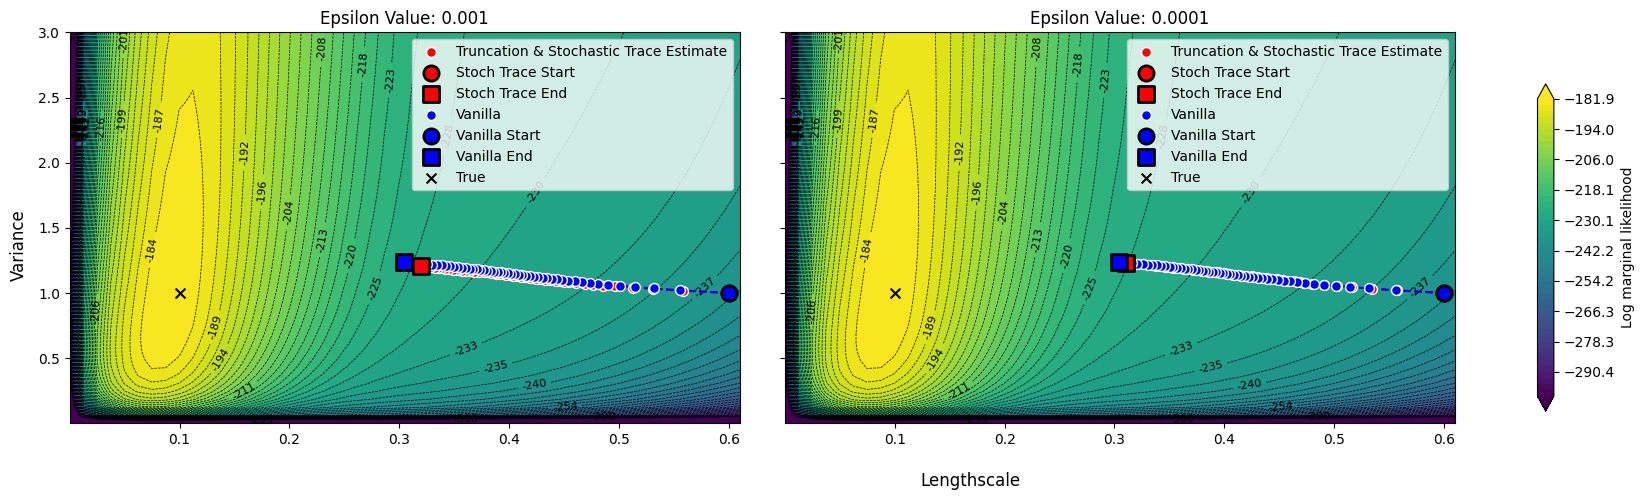

In [77]:
# Clip values below -100 to prevent extreme low outliers
log_marginal_clipped = np.clip(log_marginals_grid, -100, log_marginals_grid.max())
log_marginal_clipped = log_marginals_grid

# Set up filled contour levels (detailed)
fill_levels = np.linspace(-300, log_marginals_grid.max(), 50)
line_levels = np.linspace(-300, log_marginals_grid.max(), 50)

n_plots = len(results)
n_rows = 1
n_cols = int(np.ceil(n_plots / n_rows))
tracked_lengthscales_vanilla_arr = np.array(tracked_lengthscales_vanilla)
tracked_variances_vanilla_arr = np.array(tracked_variances_vanilla)

# Prepare Adam path from training_log if available
if 'training_log' in globals() or 'training_log' in locals():
    adam_lengthscales = np.array(training_log['lengthscale'])
    adam_variances = np.array(training_log['variance'])
else:
    adam_lengthscales = np.array([])
    adam_variances = np.array([])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5), sharex=True, sharey=True)
if isinstance(axes, np.ndarray):
    axes = axes.ravel()
else:
    axes = np.array([axes])

for i, ax in enumerate(axes):
    if i < n_plots:
        cf = ax.contourf(lengthscales, variances, log_marginal_clipped.T,
                         levels=fill_levels, cmap='viridis', extend='both')
        cs = ax.contour(lengthscales, variances, log_marginal_clipped.T,
                        levels=line_levels, colors='k', linewidths=0.5)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%1.0f')

        # Stochastic Trace Estimate path
        tracked_lengthscales_arr = np.array(results[i].get('tracked_lengthscales', []))
        tracked_variances_arr = np.array(results[i].get('tracked_variances', []))
        ax.scatter(tracked_lengthscales_arr, tracked_variances_arr,
                   color='red', edgecolors='w', s=50, label='Truncation & Stochastic Trace Estimate', zorder=10)
        ax.plot(tracked_lengthscales_arr, tracked_variances_arr,
                color='red', linestyle='--', zorder=9)
        # Mark first and last point for stochastic trace path
        if len(tracked_lengthscales_arr) > 0:
            ax.scatter(tracked_lengthscales_arr[0], tracked_variances_arr[0],
                       color='red', marker='o', s=120, edgecolors='k', linewidths=2, label='Stoch Trace Start', zorder=15)
            ax.scatter(tracked_lengthscales_arr[-1], tracked_variances_arr[-1],
                       color='red', marker='s', s=120, edgecolors='k', linewidths=2, label='Stoch Trace End', zorder=15)

        # Vanilla path
        ax.scatter(tracked_lengthscales_vanilla_arr, tracked_variances_vanilla_arr,
                   color='blue', edgecolors='w', s=50, label='Vanilla', zorder=10)
        ax.plot(tracked_lengthscales_vanilla_arr, tracked_variances_vanilla_arr,
                color='blue', linestyle='--', zorder=9)
        # Mark first and last point for vanilla path
        if len(tracked_lengthscales_vanilla_arr) > 0:
            ax.scatter(tracked_lengthscales_vanilla_arr[0], tracked_variances_vanilla_arr[0],
                       color='blue', marker='o', s=120, edgecolors='k', linewidths=2, label='Vanilla Start', zorder=15)
            ax.scatter(tracked_lengthscales_vanilla_arr[-1], tracked_variances_vanilla_arr[-1],
                       color='blue', marker='s', s=120, edgecolors='k', linewidths=2, label='Vanilla End', zorder=15)

        # Adam path from training_log if available
        # if 'adam_lengthscales' in globals() and 'adam_variances' in globals():
        #     ax.scatter(adam_lengthscales, adam_variances,
        #                color='purple', edgecolors='w', s=50, label='Adam path', zorder=11)
        #     ax.plot(adam_lengthscales, adam_variances,
        #             color='purple', linestyle='-', zorder=10)
        #     # Mark first and last point for Adam path
        #     if len(adam_lengthscales) > 0:
        #         ax.scatter(adam_lengthscales[0], adam_variances[0],
        #                    color='purple', marker='o', s=120, edgecolors='k', linewidths=2, label='Adam Start', zorder=15)
        #         ax.scatter(adam_lengthscales[-1], adam_variances[-1],
        #                    color='purple', marker='s', s=120, edgecolors='k', linewidths=2, label='Adam End', zorder=15)

        ax.scatter(true_length_scale, true_variance, color='black', edgecolors='w', s=50, marker='x', label='True', zorder=12)

        # if 'scikit_length_scale' in globals() and 'scikit_variance' in globals():
        #     ax.scatter(float(scikit_length_scale), float(scikit_variance), 
        #                color='orange', edgecolors='w', s=70, marker='*', label='Scikit-learn', zorder=13)

        # ax.set_title(f"Trace Samples: {results[i]['trace_samples']}, Epsilon Value: {results[i]['epsilon']}", fontsize=12)
        ax.set_title(f"Epsilon Value: {results[i]['epsilon']}", fontsize=12)
        # To avoid duplicate legend entries, use unique handles/labels
        handles, labels = ax.get_legend_handles_labels()
        from collections import OrderedDict
        by_label = OrderedDict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=10)
    else:
        ax.axis('off')

cbar = fig.colorbar(cf, ax=axes.tolist(), label='Log marginal likelihood', shrink=0.85, orientation='vertical', pad=0.02)
cbar.ax.tick_params(labelsize=10)
fig.supxlabel('Lengthscale', fontsize=12)
fig.supylabel('Variance', fontsize=12)
# plt.suptitle('Vanilla, Stochastic Trace Estimate', fontsize=14)
plt.tight_layout(rect=[.01, 0, 0.75, 1])
plt.show()


Plotting result for smallest epsilon: 0.0001


/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_13388/1062392744.py:58: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(true_length_scale, true_variance, color='black', edgecolors='w', s=50, marker='x', label='True', zorder=12)


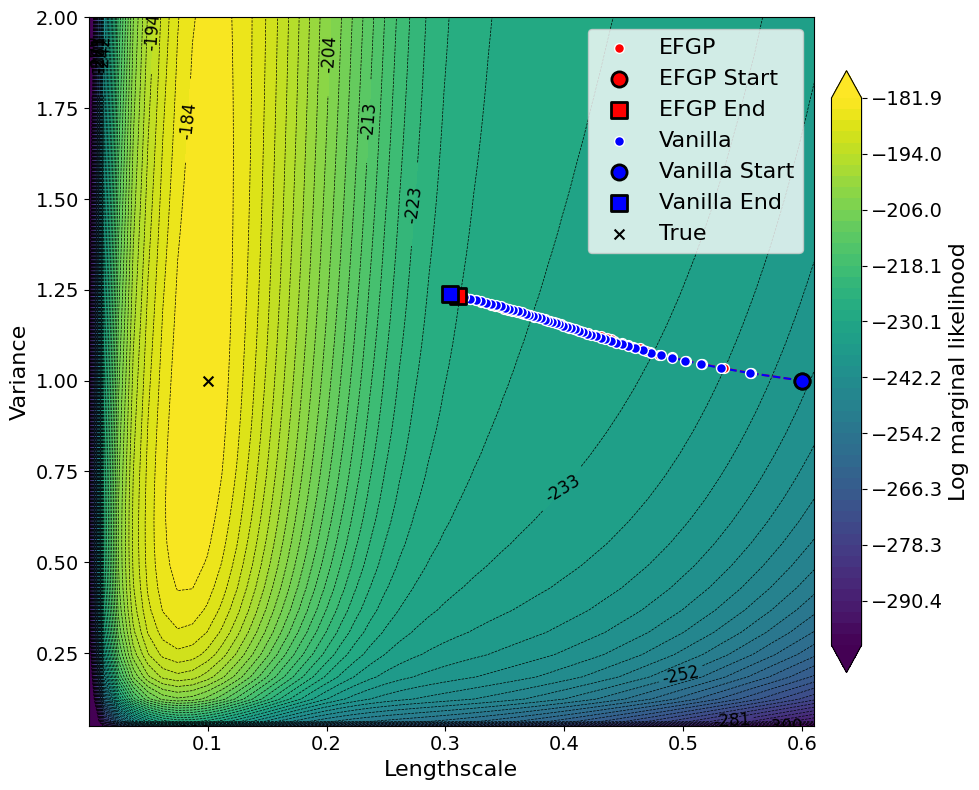

In [78]:
# Plot only the smallest epsilon value
# Find the result with the smallest epsilon value
min_epsilon_result = min(results, key=lambda x: x['epsilon'])
print(f"Plotting result for smallest epsilon: {min_epsilon_result['epsilon']}")

# Clip values below -100 to prevent extreme low outliers
log_marginal_clipped = np.clip(log_marginals_grid, -100, log_marginals_grid.max())
log_marginal_clipped = log_marginals_grid

# Set up filled contour levels (detailed)
fill_levels = np.linspace(-300, log_marginals_grid.max(), 50)
# Keep detailed contour lines but label fewer of them
line_levels = np.linspace(-300, log_marginals_grid.max(), 50)
# Create a subset of levels to label (every 4th level)
label_levels = line_levels[::4]

tracked_lengthscales_vanilla_arr = np.array(tracked_lengthscales_vanilla)
tracked_variances_vanilla_arr = np.array(tracked_variances_vanilla)

# Create a single plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot the filled contours
cf = ax.contourf(lengthscales, variances, log_marginal_clipped.T,
                 levels=fill_levels, cmap='viridis', extend='both')
cs = ax.contour(lengthscales, variances, log_marginal_clipped.T,
                levels=line_levels, colors='k', linewidths=0.5)
# Only label the subset of contours
ax.clabel(cs, levels=label_levels, inline=True, fontsize=12, fmt='%1.0f')

# Stochastic Trace Estimate path for smallest epsilon
tracked_lengthscales_arr = np.array(min_epsilon_result.get('tracked_lengthscales', []))
tracked_variances_arr = np.array(min_epsilon_result.get('tracked_variances', []))
ax.scatter(tracked_lengthscales_arr, tracked_variances_arr,
           color='red', edgecolors='w', s=50, label='EFGP', zorder=10)
ax.plot(tracked_lengthscales_arr, tracked_variances_arr,
        color='red', linestyle='--', zorder=9)
# Mark first and last point for stochastic trace path
if len(tracked_lengthscales_arr) > 0:
    ax.scatter(tracked_lengthscales_arr[0], tracked_variances_arr[0],
               color='red', marker='o', s=120, edgecolors='k', linewidths=2, label='EFGP Start', zorder=15)
    ax.scatter(tracked_lengthscales_arr[-1], tracked_variances_arr[-1],
               color='red', marker='s', s=120, edgecolors='k', linewidths=2, label='EFGP End', zorder=15)

# Vanilla path
ax.scatter(tracked_lengthscales_vanilla_arr, tracked_variances_vanilla_arr,
           color='blue', edgecolors='w', s=50, label='Vanilla', zorder=10)
ax.plot(tracked_lengthscales_vanilla_arr, tracked_variances_vanilla_arr,
        color='blue', linestyle='--', zorder=9)
# Mark first and last point for vanilla path
if len(tracked_lengthscales_vanilla_arr) > 0:
    ax.scatter(tracked_lengthscales_vanilla_arr[0], tracked_variances_vanilla_arr[0],
               color='blue', marker='o', s=120, edgecolors='k', linewidths=2, label='Vanilla Start', zorder=15)
    ax.scatter(tracked_lengthscales_vanilla_arr[-1], tracked_variances_vanilla_arr[-1],
               color='blue', marker='s', s=120, edgecolors='k', linewidths=2, label='Vanilla End', zorder=15)

# True values
ax.scatter(true_length_scale, true_variance, color='black', edgecolors='w', s=50, marker='x', label='True', zorder=12)
ax.set_ylim(0.05, 2)
# ax.set_title(f"Epsilon Value: {min_epsilon_result['epsilon']}", fontsize=14)
# To avoid duplicate legend entries, use unique handles/labels
handles, labels = ax.get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=16)

# Add colorbar
cbar = fig.colorbar(cf, ax=ax, label='Log marginal likelihood', shrink=0.85, orientation='vertical', pad=0.02)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Log marginal likelihood', fontsize=16)

ax.set_xlabel('Lengthscale', fontsize=16)
ax.set_ylabel('Variance', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()


# Agrees with Gpytorch as well 

In [79]:
# import gpytorch
# sigmasq = torch.tensor(0.1, dtype=torch.float64)  # noise variance

# # ─── 1) Assume you already have these:
# #    train_x, train_y: your data tensors
# #    init_kernel:      an object with .lengthscale and .variance
# #    sigmasq:          a tensor (or scalar tensor) for your noise variance
# # ─────────────────────────────────────────────────────────────────────────

# # ─── 2) Define your Exact GP
# class ExactGPModel(gpytorch.models.ExactGP):
#     def __init__(self, x, y, likelihood):
#         super().__init__(x, y, likelihood)
#         self.mean_module = gpytorch.means.ConstantMean()
#         self.covar_module = gpytorch.kernels.ScaleKernel(
#             gpytorch.kernels.RBFKernel()
#         )
#     def forward(self, x):
#         return gpytorch.distributions.MultivariateNormal(
#             self.mean_module(x),
#             self.covar_module(x)
#         )

# likelihood = gpytorch.likelihoods.GaussianLikelihood()
# model      = ExactGPModel(x, y, likelihood)

# # Initialize to match your “init_kernel”
# # Ensure init_kernel.lengthscale and variance are torch tensors
# # --- Fix: Ensure lengthscale and variance are at least 1D tensors ---
# def ensure_1d_tensor(val, dtype, device):
#     t = torch.as_tensor(val, dtype=dtype, device=device)
#     if t.ndim == 0:
#         t = t.unsqueeze(0)
#     return t

# lengthscale_tensor = ensure_1d_tensor(
#     init_kernel.lengthscale,
#     dtype=model.covar_module.base_kernel.raw_lengthscale.dtype,
#     device=model.covar_module.base_kernel.raw_lengthscale.device
# )
# variance_tensor = ensure_1d_tensor(
#     init_kernel.variance,
#     dtype=model.covar_module.raw_outputscale.dtype,
#     device=model.covar_module.raw_outputscale.device
# )
# sigmasq_tensor = torch.as_tensor(sigmasq, dtype=likelihood.raw_noise.dtype, device=likelihood.raw_noise.device)

# model.covar_module.base_kernel.raw_lengthscale.data = \
#     model.covar_module.base_kernel.raw_lengthscale_constraint.inverse_transform(
#         lengthscale_tensor
#     )
# model.covar_module.outputscale = variance_tensor
# likelihood.noise = sigmasq_tensor

# model.train()
# likelihood.train()

# # ─── 3) Set up optimizer + MLL
# optimizer = torch.optim.Adam(
#     list(model.parameters()) + list(likelihood.parameters()), lr=1e-3
# )
# mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

# # ─── 4) One gradient step, but *rescale* to get the full‐N data gradient
# optimizer.zero_grad()
# output   = model(x)
# loss_avg = -mll(output, y)               # this is (1/n)×NLL
# n_data   = y.numel()
# loss_full= loss_avg * n_data                   # now it’s the true NLL
# loss_full.backward()

# # ─── 5) Extract raw gradient ∂Loss/∂ρ
# raw_param = model.covar_module.base_kernel.raw_lengthscale
# raw_grad  = raw_param.grad                     # ∂NLL/∂ρ

# # ─── 6) Compute dℓ/dρ via the constraint’s transform
# constraint  = model.covar_module.base_kernel.raw_lengthscale_constraint
# raw_for_jac = raw_param.detach().clone().requires_grad_(True)
# ℓ_for_jac    = constraint.transform(raw_for_jac) 
# (dldρ,)      = torch.autograd.grad(ℓ_for_jac, raw_for_jac)

# # ─── 7) Chain rule: ∂NLL/∂ℓ = (∂NLL/∂ρ) / (dℓ/dρ)
# dLoss_dℓ = raw_grad / dldρ

# # If the lengthscale is a 1-element tensor, print the scalar value
# if dLoss_dℓ.numel() == 1:
#     print(f"Raw grad     ∂NLL/∂ρ   = {raw_grad.item(): .6f}")
#     print(f"dℓ/dρ               = {dldρ.item(): .6f}")
#     print(f"True grad ∂NLL/∂ℓ    = {dLoss_dℓ.item(): .6f}")
# else:
#     print(f"Raw grad     ∂NLL/∂ρ   = {raw_grad}")
#     print(f"dℓ/dρ               = {dldρ}")
#     print(f"True grad ∂NLL/∂ℓ    = {dLoss_dℓ}")


$$\alpha = (K+\sigma^2 I)^{-1}y$$

$$\frac{\partial (K + \sigma^2 I)}{\partial \theta} = FD'F^* + \frac{\partial (\sigma^2 I)}{\partial \theta}$$
where 
$$D'_{jj} = h^d\frac{\partial }{\partial \theta} \hat{k}_\theta(\xi_j)